# 03 — Full dev set: speaker-grouped CV, Ridge vs Random Forest vs MLP

Notebooks 01–02 worked on a 100-response sample. This notebook scales to the **full scored
long-turn dev set** — Parts 3 and 4, 876 responses from 438 speakers, one human score each —
and asks:

1. Do the notebook-02 findings hold at 9× the sample size?
2. **Does speaker leakage inflate results?** Every speaker contributes two responses (P3 + P4);
   random CV folds put the same speaker in train and test. All headline numbers here use
   `GroupKFold` by speaker — and the leakage is quantified explicitly.
3. Do non-linear models (Random Forest, a small PyTorch MLP) beat Ridge on these features?
4. Where does the error live? (per-band MAE — the seed of the error-analysis report)

Code now imports from the `speechlab` package (notebooks 01–02 remain frozen records).
LLM-derived grammar/coherence features are deferred to the next notebook.

*Licence note: all outputs are aggregates — no per-speaker rows, no transcript text.*

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf

from speechlab.data import load_responses
from speechlab.acoustic_features import fluency_features, FLUENCY_FEATURES, PROSODY_FEATURES
from speechlab.text_features import mtld, normalise_tokens
from speechlab.evaluation import evaluate

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data" / "sandi-corpus-2025").exists(), f"corpus not found under {ROOT}"

CORPUS = ROOT / "data" / "sandi-corpus-2025"
DERIVED = ROOT / "data" / "derived"
PARTS = ["P3", "P4"]          # long single turns: one response, one score
SEED = 42

print(f"project root: {ROOT.name}/  |  parts: {PARTS}")

project root: speech_scoring_evaluation_lab/  |  parts: ['P3', 'P4']


## 1. Assemble the feature matrix

Transcripts come from the full-dev Whisper cache (`scripts/transcribe_dev.py`), prosody from
the parselmouth cache (`scripts/extract_prosody.py`). Features are exactly the notebook-02
set, computed by `speechlab`: 11 fluency features (MTLD alongside TTR) + 5 prosody features,
plus a part indicator so the pooled model can absorb task-level differences.

In [2]:
frames = []
for part in PARTS:
    df = load_responses(CORPUS, part)
    trans = json.load(open(DERIVED / f"transcripts_{part}_small.json"))
    pros = json.load(open(DERIVED / f"prosody_{part}_full.json"))
    rows = []
    for r in df.itertuples():
        words = trans[r.utt]
        duration = sf.info(str(CORPUS / r.flac)).duration
        rows.append({"utt": r.utt, "speaker": r.speaker, "part": part, "score": r.score,
                     **fluency_features(words, duration),
                     "mtld": mtld(normalise_tokens([w["w"] for w in words])),
                     **pros[r.utt]})
    frames.append(pd.DataFrame(rows))

data = pd.concat(frames, ignore_index=True)
empty = data[data.n_words == 0]
if len(empty):
    print(f"excluding {len(empty)} silent/failed-ASR responses")
    data = data[data.n_words > 0].reset_index(drop=True)
data["part_p4"] = (data.part == "P4").astype(float)

print(f"responses: {len(data)} from {data.speaker.nunique()} speakers")
print(data.groupby("part").score.describe().round(2)[["count", "mean", "std", "min", "max"]])

responses: 876 from 438 speakers
      count  mean   std  min  max
part                             
P3    438.0  4.03  0.73  2.0  5.5
P4    438.0  3.86  0.73  2.0  5.5


## 2. Speaker-grouped cross-validation

A speaker's P3 and P4 scores are two measurements of the same underlying proficiency — they
correlate strongly. With random folds, the model effectively *sees the test speaker during
training* through their other response: speaker identity leaks, and every metric inflates.

All headline results therefore use `GroupKFold(5)` with the speaker as the group: no speaker
ever appears in both train and test. Section 4 measures exactly how much the naive split
flatters the models.

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from speechlab.scoring_models import TorchMLPRegressor

F_MTLD = [f if f != "ttr" else "mtld" for f in FLUENCY_FEATURES]
FEATURES = F_MTLD + PROSODY_FEATURES + ["part_p4"]

y = data.score.to_numpy()
groups = data.speaker.to_numpy()
cv_grouped = GroupKFold(n_splits=5)

models = {
    "mean predictor": (None, None),
    "word-count Ridge": (make_pipeline(StandardScaler(), Ridge(alpha=1.0)), ["n_words", "part_p4"]),
    "Ridge": (make_pipeline(StandardScaler(), Ridge(alpha=1.0)), FEATURES),
    "Random Forest": (RandomForestRegressor(n_estimators=500, min_samples_leaf=5,
                                            random_state=SEED, n_jobs=-1), FEATURES),
    "MLP (PyTorch)": (make_pipeline(StandardScaler(), TorchMLPRegressor(seed=SEED)), FEATURES),
}

preds = {}
for name, (est, cols) in models.items():
    if est is None:
        preds[name] = np.full_like(y, y.mean())
        continue
    preds[name] = cross_val_predict(est, data[cols].to_numpy(), y,
                                    cv=cv_grouped, groups=groups)
    print(f"{name}: done", flush=True)

results = pd.DataFrame({n: evaluate(y, p) for n, p in preds.items()}).T
results.round(3)

word-count Ridge: done


Ridge: done


Random Forest: done


MLP (PyTorch): done


,pearson_r,spearman_rho,MAE,RMSE,QWK
mean predictor,NaN,NaN,0.580,0.733,0.000
word-count Ridge,0.589,0.599,0.474,0.593,0.500
Ridge,0.609,0.610,0.464,0.582,0.548
Random Forest,0.622,0.625,0.456,0.575,0.558
MLP (PyTorch),0.483,0.486,0.580,0.727,0.475


## 3. Per-part breakdown

One pooled model, evaluated separately on each part — does it score one task type better
than the other?

In [4]:
per_part = {}
for name in ["Ridge", "Random Forest", "MLP (PyTorch)"]:
    for part in PARTS:
        mask = (data.part == part).to_numpy()
        per_part[(name, part)] = evaluate(y[mask], preds[name][mask])
pp = pd.DataFrame(per_part).T[["pearson_r", "MAE", "QWK"]]
pp.index.names = ["model", "part"]
pp.round(3)

pearson_r    MAE    QWK
model         part                         
Ridge         P3        0.648  0.442  0.598
              P4        0.553  0.487  0.474
Random Forest P3        0.664  0.433  0.604
              P4        0.563  0.480  0.496
MLP (PyTorch) P3        0.530  0.550  0.513
              P4        0.423  0.610  0.425

## 4. The leakage exhibit: grouped vs naive CV

Same models, same features, same data — the only change is the fold assignment
(`KFold(shuffle=True)` instead of `GroupKFold` by speaker).

In [5]:
cv_naive = KFold(n_splits=5, shuffle=True, random_state=SEED)
leak = {}
for name in ["Ridge", "Random Forest"]:
    est, cols = models[name]
    p_naive = cross_val_predict(est, data[cols].to_numpy(), y, cv=cv_naive)
    leak[name] = {
        "QWK grouped": evaluate(y, preds[name])["QWK"],
        "QWK naive": evaluate(y, p_naive)["QWK"],
    }
leak_df = pd.DataFrame(leak).T
leak_df["inflation"] = leak_df["QWK naive"] - leak_df["QWK grouped"]
leak_df.round(3)

,QWK grouped,QWK naive,inflation
Ridge,0.548,0.563,0.015
Random Forest,0.558,0.557,-0.000


## 5. Where the error lives

Mean absolute error by integer score band — scarce-band speakers are exactly where automated
scoring decisions are most consequential.

best model: Random Forest
        n    MAE
band            
2      42  0.964
3     290  0.455
4     412  0.327
5     132  0.701


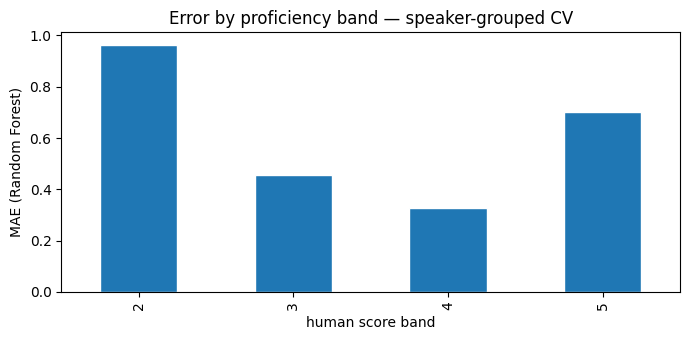

In [6]:
import matplotlib.pyplot as plt

best = results.QWK.idxmax()
band = data.score.clip(1, 5.99).astype(int)
err = pd.DataFrame({"band": band, "abs_err": np.abs(preds[best] - y)})
by_band = err.groupby("band").agg(n=("abs_err", "size"), MAE=("abs_err", "mean")).round(3)
print(f"best model: {best}")
print(by_band)

fig, ax = plt.subplots(figsize=(7, 3.5))
by_band.MAE.plot.bar(ax=ax, edgecolor="white")
ax.set_xlabel("human score band")
ax.set_ylabel(f"MAE ({best})")
ax.set_title("Error by proficiency band — speaker-grouped CV")
plt.tight_layout()

## 6. What the forest looks at

Impurity-based importances from one fit on all rows (descriptive, not causal — correlated
features share credit).

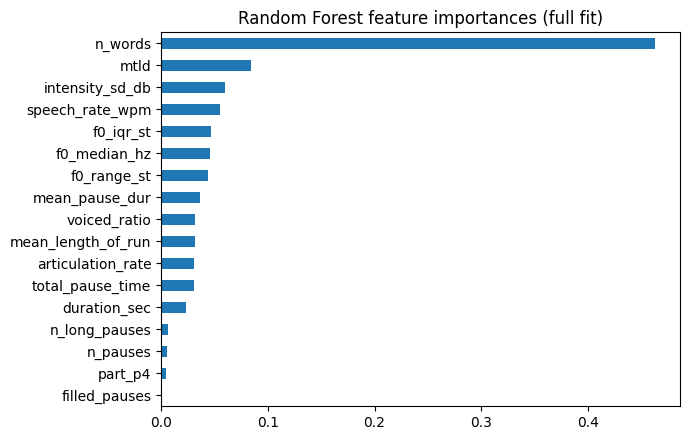

In [7]:
rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=5, random_state=SEED, n_jobs=-1)
rf.fit(data[FEATURES].to_numpy(), y)
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
imp.plot.barh(ax=ax)
ax.set_title("Random Forest feature importances (full fit)")
plt.tight_layout()

## Findings

**Scale corrects the small-sample optimism.** The 100-response numbers were inflated: on the
same P3 task the best model drops from QWK 0.647 (n=100, notebook 02) to **0.604** at n=438,
and the pooled P3+P4 headline is **0.558**. Notebook 02's warning that fold assignment alone
swings QWK by ±0.04 at n=100 materialised — the full-set numbers are the trustworthy ones.

**P4 is systematically harder to score than P3** — RF QWK 0.604 (P3) vs 0.496 (P4), r 0.66 vs
0.56, with the same features and the same speakers. Task-level differences matter; a per-part
error analysis belongs in the evaluation report.

**Speaker leakage was minimal — but now it's measured, not assumed.** Naive random folds
inflate Ridge by just +0.015 QWK and RF by nothing. The grouped protocol stays (it is the
correct design and costs nothing), and the null itself is informative: these 17 handcrafted
features barely fingerprint individual speakers beyond their proficiency.

**Random Forest edges Ridge** (0.558 vs 0.548 QWK) — non-linearity buys little on 17
engineered features. **The MLP loses outright** (0.475, worse than word count): an honest
null — 876 rows is too few for even a small neural model at default settings, and it stays
in the table as a baseline for when features (or data) grow.

**Error concentrates at the extremes**: MAE 0.96 at band 2 and 0.70 at band 5, versus 0.33
at band 4 where the data mass sits — textbook regression to the mean. The scorer is least
reliable exactly where scoring decisions matter most (the weakest candidates). This is the
flagship input to the fairness and error-analysis reports.

**Next:** error analysis and fairness slices at full scale (audio-quality bands, per-part);
LLM-derived grammar/coherence features (separate notebook, needs API access); P1/P5 short
responses once transcription completes.